In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('C:/Users/Win10/Documents/clean_delay_analysis.csv')
header = None
df.columns =['order_id','order_purchase_timestamp','order_estimated_delivery_date','order_delivered_customer_date','order_status','customer_city','customer_state','seller_city','seller_state','price','freight_value','payment_type','payment_value','product_weight_g','product_length_cm','product_height_cm','product_width_cm','product_category_name','review_score','delay_days']


sql_df=pd.read_csv('C:/Users/Win10/Documents/seller_id.csv')
header=None
sql_df.columns=['order_id','seller_id']

sql2_df=pd.read_csv('C:/Users/Win10/Documents/shipping.csv')
header=None
sql2_df.columns=['order_id','shipping_limit_date']

sql3_df=pd.read_csv('C:/Users/Win10/Documents/order_delivered_carrier_date.csv')
header=None
sql3_df.columns=['order_id','order_approved_at','order_delivered_carrier_date']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98656 entries, 0 to 98655
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       98656 non-null  object 
 1   order_purchase_timestamp       98656 non-null  object 
 2   order_estimated_delivery_date  98656 non-null  object 
 3   order_delivered_customer_date  96474 non-null  object 
 4   order_status                   98656 non-null  object 
 5   customer_city                  98656 non-null  object 
 6   customer_state                 98656 non-null  object 
 7   seller_city                    98656 non-null  object 
 8   seller_state                   98656 non-null  object 
 9   price                          98656 non-null  float64
 10  freight_value                  98656 non-null  float64
 11  payment_type                   98656 non-null  object 
 12  payment_value                  98656 non-null 

In [8]:
df.describe()

,price,freight_value,payment_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score,delay_days
count,98656.000000,98656.000000,98656.000000,98640.000000,98640.000000,98640.000000,98640.000000,97907.000000,96474.000000
mean,125.963380,20.202496,157.954210,2102.652271,30.107036,16.487824,23.025558,4.105100,-11.877407
std,191.383054,15.910463,218.122181,3765.805210,16.129352,13.325802,11.742109,1.331277,10.182789
min,0.850000,0.000000,0.000000,0.000000,7.000000,2.000000,6.000000,1.000000,-147.000000
25%,41.500000,13.310000,60.049999,300.000000,18.000000,8.000000,15.000000,4.000000,-17.000000
50%,79.000000,16.360001,103.279999,700.000000,25.000000,13.000000,20.000000,5.000000,-12.000000
75%,139.899994,21.230000,175.080002,1800.000000,38.000000,20.000000,30.000000,5.000000,-7.000000
max,6735.000000,409.679993,13664.080078,40425.000000,105.000000,105.000000,118.000000,5.000000,188.000000


In [9]:
df=df.drop_duplicates(subset='order_id')

In [10]:
df['order_id'].duplicated().sum()

0

In [11]:
df.isnull().sum()

order_id                            0
order_purchase_timestamp            0
order_estimated_delivery_date       0
order_delivered_customer_date    2182
order_status                        0
customer_city                       0
customer_state                      0
seller_city                         0
seller_state                        0
price                               0
freight_value                       0
payment_type                        0
payment_value                       0
product_weight_g                   16
product_length_cm                  16
product_height_cm                  16
product_width_cm                   16
product_category_name               0
review_score                      749
delay_days                       2182
dtype: int64

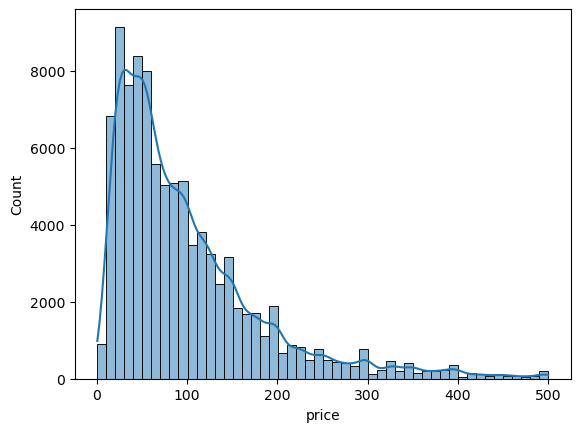

In [12]:
sns.histplot(df[df['price']< 500]['price'],bins=50,kde=True)
plt.show()


In [13]:
139.899994 - 41.500000

98.39999399999999

In [14]:
upper_bound = 139.9+1.5*98

In [15]:
df[df['price']>287].shape

(7601, 20)

In [16]:
df.groupby('product_category_name')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
product_category_name,,,,,,,,
agro_industria_e_comercio,182.0,351.844395,428.968255,12.99,44.474999,299.949997,428.000000,2990.000000
alimentos,444.0,59.633941,42.045018,9.99,27.900000,52.500000,81.122499,274.989990
alimentos_bebidas,224.0,60.082322,74.108859,6.50,26.700001,39.945002,58.320000,699.900024
artes,198.0,118.223182,457.712711,3.50,51.242501,99.000000,99.989998,6499.000000
artes_e_artesanato,22.0,79.641818,76.042796,9.80,19.200000,49.900002,128.740004,289.489990
...,...,...,...,...,...,...,...,...
tablets_impressao_imagem,77.0,90.579351,96.585602,14.90,54.900002,99.000000,99.000000,889.989990
telefonia,4182.0,72.225380,140.122519,5.00,21.990000,29.980000,49.000000,2428.000000
telefonia_fixa,217.0,165.134193,308.718501,6.00,19.990000,44.000000,139.000000,1790.000000


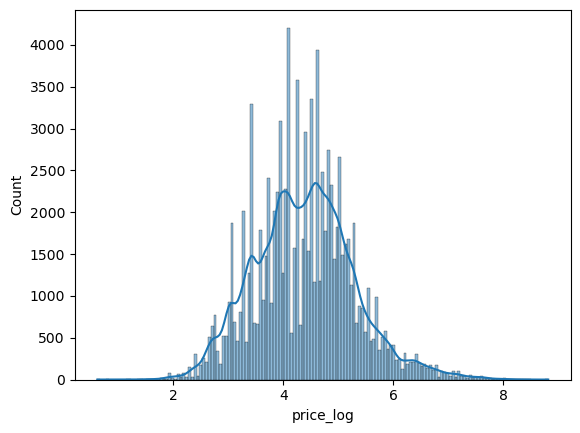

In [17]:
df['price_log']= np.log1p(df['price'])
sns.histplot(df['price_log'],kde=True)
plt.show()

<Axes: xlabel='order_status', ylabel='price_log'>

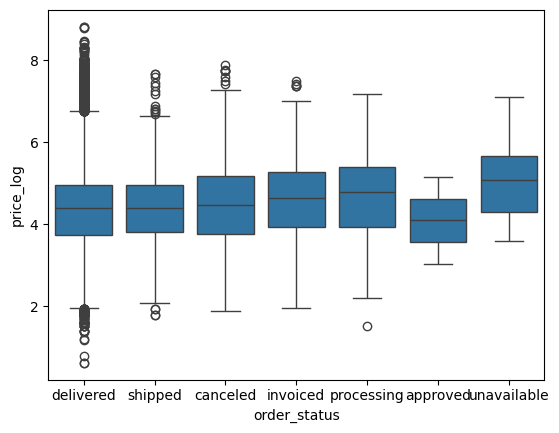

In [18]:
sns.boxplot(x='order_status',y='price_log',data=df)

In [19]:
df['is_delayed']=df['delay_days']>0

In [20]:
df.head()

,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,order_status,customer_city,customer_state,seller_city,seller_state,price,...,payment_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name,review_score,delay_days,price_log,is_delayed
0,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06.0000000,2017-05-15 00:00:00.0000000,2017-05-12 16:04:24.0000000,delivered,santa fe do sul,SP,sao paulo,SP,239.899994,...,259.829987,30000.0,50.0,30.0,40.0,pet_shop,4.0,-3.0,5.484382,False
1,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31.0000000,2018-02-05 00:00:00.0000000,2018-01-22 13:19:16.0000000,delivered,para de minas,MG,borda da mata,MG,199.000000,...,216.869995,3050.0,33.0,13.0,33.0,moveis_decoracao,5.0,-14.0,5.298317,False
2,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35.0000000,2018-08-20 00:00:00.0000000,2018-08-14 13:32:39.0000000,delivered,atibaia,SP,franca,SP,12.990000,...,25.780001,200.0,16.0,10.0,15.0,perfumaria,4.0,-6.0,2.638343,False
3,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51.0000000,2017-03-17 00:00:00.0000000,2017-03-01 16:42:31.0000000,delivered,varzea paulista,SP,loanda,PR,199.899994,...,218.039993,3750.0,35.0,40.0,30.0,ferramentas_jardim,5.0,-16.0,5.302807,False
4,00048cc3ae777c65dbb7d2a0634bc1ea,2017-05-15 21:42:34.0000000,2017-06-06 00:00:00.0000000,2017-05-22 13:44:35.0000000,delivered,uberaba,MG,ribeirao preto,SP,21.900000,...,34.590000,450.0,24.0,8.0,15.0,utilidades_domesticas,4.0,-15.0,3.131137,False


In [21]:
df['is_delayed'].value_counts(normalize=True)*100

is_delayed
False    93.376987
True      6.623013
Name: proportion, dtype: float64

In [22]:
df.groupby('is_delayed')['price'].mean()

is_delayed
False    124.820470
True     142.077117
Name: price, dtype: float64

 Delayed orders tend to have slightly higher average prices compared to on-time deliveries. However, the difference is not substantial,
and with only ~6.6% delayed orders, price does not appear to be a strong driver of delivery delays

<Axes: xlabel='is_delayed', ylabel='price_log'>

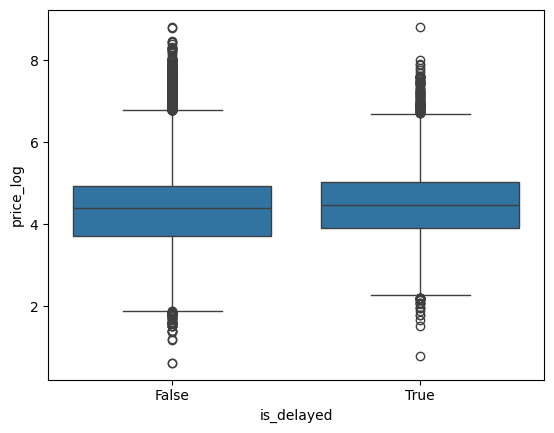

In [67]:

sns.boxplot(x='is_delayed',y='price_log',data=df)

### Insight
No clear difference_price does not strongly affect delay

In [25]:
df.head()

,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,order_status,customer_city,customer_state,seller_city,seller_state,price,...,payment_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name,review_score,delay_days,price_log,is_delayed
0,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06.0000000,2017-05-15 00:00:00.0000000,2017-05-12 16:04:24.0000000,delivered,santa fe do sul,SP,sao paulo,SP,239.899994,...,259.829987,30000.0,50.0,30.0,40.0,pet_shop,4.0,-3.0,5.484382,False
1,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31.0000000,2018-02-05 00:00:00.0000000,2018-01-22 13:19:16.0000000,delivered,para de minas,MG,borda da mata,MG,199.000000,...,216.869995,3050.0,33.0,13.0,33.0,moveis_decoracao,5.0,-14.0,5.298317,False
2,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35.0000000,2018-08-20 00:00:00.0000000,2018-08-14 13:32:39.0000000,delivered,atibaia,SP,franca,SP,12.990000,...,25.780001,200.0,16.0,10.0,15.0,perfumaria,4.0,-6.0,2.638343,False
3,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51.0000000,2017-03-17 00:00:00.0000000,2017-03-01 16:42:31.0000000,delivered,varzea paulista,SP,loanda,PR,199.899994,...,218.039993,3750.0,35.0,40.0,30.0,ferramentas_jardim,5.0,-16.0,5.302807,False
4,00048cc3ae777c65dbb7d2a0634bc1ea,2017-05-15 21:42:34.0000000,2017-06-06 00:00:00.0000000,2017-05-22 13:44:35.0000000,delivered,uberaba,MG,ribeirao preto,SP,21.900000,...,34.590000,450.0,24.0,8.0,15.0,utilidades_domesticas,4.0,-15.0,3.131137,False


**Which cutomer city has the most delay and why**

In [27]:
df.groupby('customer_city')['delay_days']\
.agg(['mean','median','count'])\
.sort_values(by= 'mean',ascending=False).head()

,mean,median,count
customer_city,,,
novo brasil,126.0,126.0,1
capinzal do norte,78.0,78.0,2
adhemar de barros,73.0,73.0,1
arace,53.0,60.0,4
serra dos dourados,52.0,52.0,1


In [28]:

city_delay=(df[df['delay_days']>0]
.groupby('customer_city')['delay_days']
.agg(['mean','count','median'])
.query('count>=30')
.sort_values(by='mean',ascending=False)).head()

In [29]:
city_delay.head()

,mean,count,median
customer_city,,,
macae,17.222222,36,12.5
fortaleza,16.351064,94,10.5
teresina,14.960784,51,7.0
belem,14.000000,38,8.0
rio de janeiro,13.339943,706,8.0


In [30]:
##Summary statistics of delay by city including mean,medianand count.

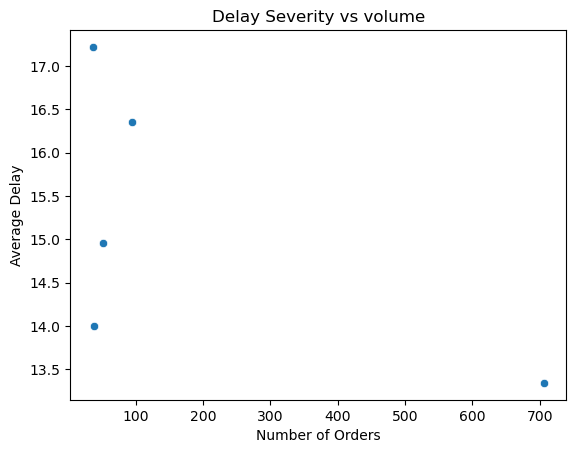

In [31]:


sns.scatterplot(data=city_delay,
x='count',
y='mean')
plt.title('Delay Severity vs volume')
plt.xlabel('Number of Orders')
plt.ylabel('Average Delay')
plt.show()

### Insight
I used a scatter plot to analze the relationship between delay severity and order volume.
-**Macae** has the highest average delay but a lower number of order volume
-**Fortaleza** also shows a strong combination of delay and volume
-**Rio de Janeiro** stands out due to high number of delayed orders,making it the most impactful city.

This analysis helps identify customer cities with higher delays and prioritize area for improvement 


### Recommendation
Improving delivery operations in **rio de janeiro** should be priortized, as it has the highest impact
on overall customer experience due to the large volume of delayed orders.

In [32]:
product_delay=df[df['delay_days']>0].groupby('product_category_name')['delay_days'].agg(['mean','count','median','sum']).query('count>=30').sort_values(by='mean',ascending=False).head()

In [33]:
product_delay

,mean,count,median,sum
product_category_name,,,,
alimentos,13.967742,31,3.0,433.0
casa_conforto,13.571429,35,9.0,475.0
moveis_escritorio,13.207921,101,7.0,1334.0
instrumentos_musicais,12.391304,46,5.5,570.0
automotivo,12.348921,278,6.0,3433.0


### Insight

-The analysis shows that most product categories have a typical (median) delay between 3 to 7 days, indicating moderate delays

-alimentos show a higher average delay possible outliers

-Although automotivo has the highest number of delayed orders (278) and the greatest total delay impact (3433 days).

-This makes automotivo the highest impact category

### Decision
-Focus on reducing delays in automotivo,as it affects the largest number of customers and contributes most to total delay.

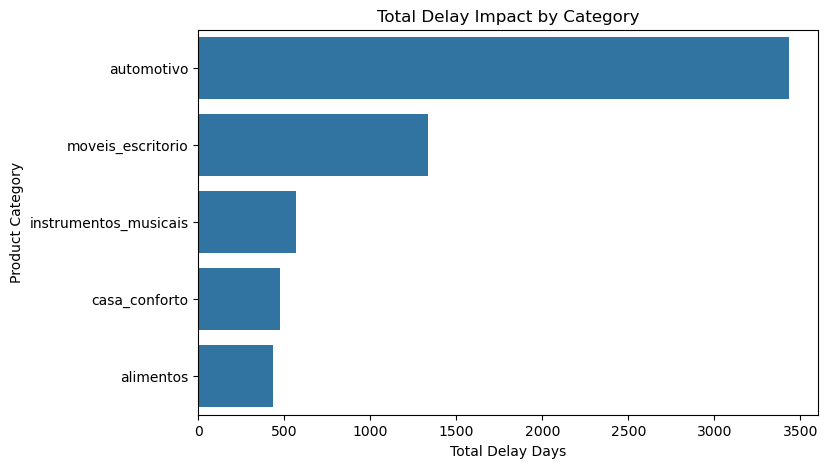

In [34]:
df_sum=product_delay.sort_values(by='sum',ascending=False).head()
plt.figure(figsize=(8,5))
sns.barplot(x=df_sum['sum'],y='product_category_name',data=df_sum)

plt.title('Total Delay Impact by Category')
plt.xlabel('Total Delay Days')
plt.ylabel('Product Category')
plt.show()



### Insight

-Automotivo contributes the highest total delay impact,indicating major operational inefficiency.

-Movies_escritorio also shows a relatively high total delay impact,making it a secondary contributor to overall delays.


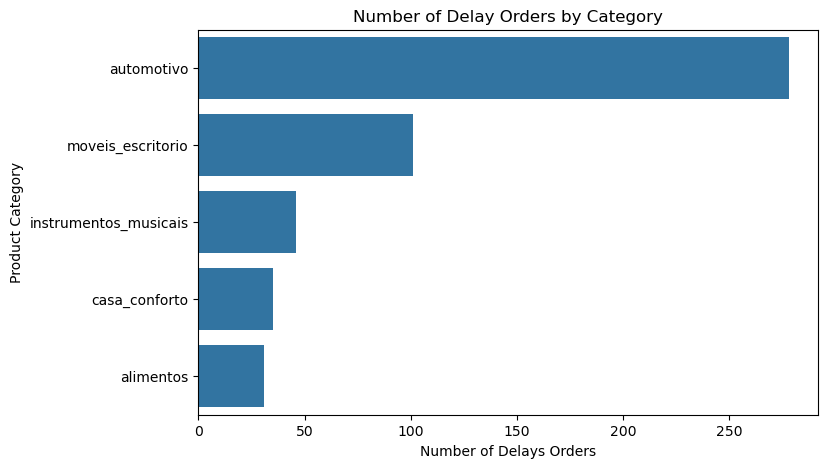

In [35]:
df_count=product_delay.sort_values(by='count',ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=df_count['count'],y='product_category_name',data=df_count)
plt.title('Number of Delay Orders by Category')
plt.xlabel('Number of Delays Orders')
plt.ylabel('Product Category')
plt.show()


### Insight
Automotivo has the highest number of delayed orders, affecting the largest number of customers.

In [36]:
df=df.merge(sql_df[['order_id','seller_id']],on='order_id',how='left')

In [37]:
df=df.merge(sql2_df[['order_id','shipping_limit_date']],on='order_id',how='left')

In [38]:
df=df.merge(sql3_df[['order_id','order_approved_at','order_delivered_carrier_date']],on='order_id',how='left')

In [40]:
df=df.drop_duplicates(subset='order_id')

In [124]:
### df=df.drop(['seller_id_y','seller_id_x','shipping_limit_date_y','order_approved_at_y','order_delivered_carrier_date_y'],axis=1)

In [42]:
df=df.rename(columns={'shipping_limit_date_x':'shipping_limit_date','order_approved_at_x':'order_approved_at','order_delivered_carrier_date_x':'order_delivered_carrier_date'})

In [ ]:
date_cols=['order_purchase_timestamp','order_estimated_delivery_date','order_delivered_customer_date','shipping_limit_date','order_approved_at','order_delivered_carrier_date']
df[date_cols]=df[date_cols].apply(lambda col:pd.to_datetime(col,errors='coerce'))

In [43]:
df_delay=df[df['delay_days']>0]

In [44]:
df_auto_rio=df[(df['product_category_name']=='automotivo')&
(df['customer_city']=='rio de janeiro')]

In [45]:
df_auto=df_delay[df_delay['product_category_name']=='automotivo']

In [46]:
183/278

0.658273381294964

In [48]:
seller_stats_auto=df_auto.groupby('seller_id')['delay_days']\
.agg(['mean','count'])\
.query('count>5')\
.sort_values(by='mean',ascending=False)

In [49]:
seller_stats_auto

,mean,count
seller_id,,
6a8b085f816a1f75f92dbac6eb545f8f,25.000000,10
712e6ed8aa4aa1fa65dab41fed5737e4,20.687500,16
c003204e1ab016dfa150abc119207b24,13.500000,6
5d0363b33554b373851fc1622e4d5f3c,12.000000,7
8581055ce74af1daba164fdbd55a40de,11.612903,31
7142540dd4c91e2237acb7e911c4eba2,11.450000,20
16090f2ca825584b5a147ab24aa30c86,10.250000,16
b1b3948701c5c72445495bd161b83a4c,10.111111,9
c9c7905cffc4ef9ff9f113554423e671,6.666667,6


In [50]:
seller_stats_auto.sort_values(by=['mean','count'],ascending=False).head()

,mean,count
seller_id,,
6a8b085f816a1f75f92dbac6eb545f8f,25.000000,10
712e6ed8aa4aa1fa65dab41fed5737e4,20.687500,16
c003204e1ab016dfa150abc119207b24,13.500000,6
5d0363b33554b373851fc1622e4d5f3c,12.000000,7
8581055ce74af1daba164fdbd55a40de,11.612903,31


In [51]:
###created impact score
seller_stats_auto['impact_score']= seller_stats_auto['mean']*seller_stats_auto['count']
seller_stats_auto.sort_values(by='impact_score',ascending=False)

,mean,count,impact_score
seller_id,,,
8581055ce74af1daba164fdbd55a40de,11.612903,31,360.0
712e6ed8aa4aa1fa65dab41fed5737e4,20.687500,16,331.0
6a8b085f816a1f75f92dbac6eb545f8f,25.000000,10,250.0
7142540dd4c91e2237acb7e911c4eba2,11.450000,20,229.0
16090f2ca825584b5a147ab24aa30c86,10.250000,16,164.0
b1b3948701c5c72445495bd161b83a4c,10.111111,9,91.0
5d0363b33554b373851fc1622e4d5f3c,12.000000,7,84.0
c003204e1ab016dfa150abc119207b24,13.500000,6,81.0
34056b8b55c1775a22af2331670a799c,5.333333,9,48.0


### Insight
A few sellers in the automotive category contribute most to delivery delays, with the top seller having the highest impact due to both high delay and high order volume.

### Decision
Focus on improving or monitoring these high-impact sellers to reduce overall delays.

In [52]:
df_rio=df_delay[df_delay['customer_city']=='rio de janeiro']

In [53]:
seller_stats_rio=df_rio.groupby('seller_id')['delay_days']\
.agg(['mean','count'])\
.query('count>5')\
.sort_values(by='mean',ascending=False)

In [54]:
seller_stats_rio

,mean,count
seller_id,,
2c9e548be18521d1c43cde1c582c6de8,27.666667,6
7d13fca15225358621be4086e1eb0964,25.714286,7
da8622b14eb17ae2831f4ac5b9dab84a,21.625000,8
8160255418d5aaa7dbdc9f4c64ebda44,17.363636,11
7c67e1448b00f6e969d365cea6b010ab,16.941176,17
8b321bb669392f5163d04c59e235e066,15.333333,18
70a12e78e608ac31179aea7f8422044b,15.333333,6
1f50f920176fa81dab994f9023523100,14.413793,29
391fc6631aebcf3004804e51b40bcf1e,13.571429,7


### Insight
Few sellers in rio de janerio causing very high delays but low order volume.


### Decision
Fix those sellers individually

In [55]:
df_target = df[(df['product_category_name'] == 'automotivo') &
               (df['customer_city'] == 'rio de janeiro') &
               (df['delay_days'] > 0)]

In [56]:
seller_stats = df_target.groupby('seller_city')['delay_days'] \
    .agg(['mean', 'count']) \
    .query('count>5')\
    .sort_values(by='mean', ascending=False)

In [57]:
seller_stats

,mean,count
seller_city,,


### Insight
Delivery delays in the automotive category in Rio de Janeiro are spread across many sellers with low order volumes, indicating that no single seller is the primary cause of delays.

### Decision
Focus on improving overall logistics and operational processes rather than targeting individual sellers, as delays are widespread across multiple sellers.

In [60]:
df_delay=df[df['delay_days']>0]
seller_stats_dataset = df_delay.groupby('seller_id')['delay_days'] \
    .agg(['mean', 'count']) \
    .query('count>30')\
    .sort_values(by='mean', ascending=False)

In [61]:
seller_stats_dataset

,mean,count
seller_id,,
cca3071e3e9bb7d12640c9fbe2301306,15.156250,32
8160255418d5aaa7dbdc9f4c64ebda44,12.745098,51
7a67c85e85bb2ce8582c35f2203ad736,12.700000,60
218d46b86c1881d022bce9c68a7d4b15,12.696970,33
e9779976487b77c6d4ac45f75ec7afe9,12.333333,39
7c67e1448b00f6e969d365cea6b010ab,12.314607,89
e5a3438891c0bfdb9394643f95273d8e,12.235294,34
8581055ce74af1daba164fdbd55a40de,11.612903,31
da8622b14eb17ae2831f4ac5b9dab84a,11.482759,87


In [62]:
df_delay = df[df['delay_days'] > 0]

seller_stats = df_delay.groupby('seller_id')['delay_days'] \
    .agg(['mean', 'count'])

seller_stats['impact_score'] = seller_stats['mean'] * seller_stats['count']

seller_stats = seller_stats.sort_values(by='impact_score', ascending=False)

seller_stats.head()

,mean,count,impact_score
seller_id,,,
4a3ca9315b744ce9f8e9374361493884,11.232558,172,1932.0
1f50f920176fa81dab994f9023523100,10.588710,124,1313.0
7c67e1448b00f6e969d365cea6b010ab,12.314607,89,1096.0
4869f7a5dfa277a7dca6462dcf3b52b2,9.245763,118,1091.0
da8622b14eb17ae2831f4ac5b9dab84a,11.482759,87,999.0


In [ ]:
### Seller processing Time

In [71]:
### how much time did seller took to prepare and hand over the order to the courier
df['seller_processing_time']=(df['order_delivered_carrier_date']-df['order_approved_at']).dt.days

In [103]:
df.head()

,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,order_status,customer_city,customer_state,seller_city,seller_state,price,...,review_score,delay_days,price_log,is_delayed,seller_id,shipping_limit_date,order_approved_at,order_delivered_carrier_date,seller_processing_time,seller_delay
0,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,2017-05-15,2017-05-12 16:04:24,delivered,santa fe do sul,SP,sao paulo,SP,239.899994,...,4.0,-3.0,5.484382,False,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,2017-04-26 11:05:13,2017-05-04 14:35:00,8.0,1.0
1,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,2018-02-05,2018-01-22 13:19:16,delivered,para de minas,MG,borda da mata,MG,199.000000,...,5.0,-14.0,5.298317,False,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,2018-01-14 14:48:30,2018-01-16 12:36:48,1.0,-3.0
2,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,2018-08-20,2018-08-14 13:32:39,delivered,atibaia,SP,franca,SP,12.990000,...,4.0,-6.0,2.638343,False,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,2018-08-08 10:10:18,2018-08-10 13:28:00,2.0,-5.0
3,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,2017-03-17,2017-03-01 16:42:31,delivered,varzea paulista,SP,loanda,PR,199.899994,...,5.0,-16.0,5.302807,False,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,11.0,2.0
4,00048cc3ae777c65dbb7d2a0634bc1ea,2017-05-15 21:42:34,2017-06-06,2017-05-22 13:44:35,delivered,uberaba,MG,ribeirao preto,SP,21.900000,...,4.0,-15.0,3.131137,False,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,2017-05-17 03:55:27,2017-05-17 11:05:55,0.0,-6.0


In [82]:
df.groupby('is_delayed')['seller_processing_time'].agg(['mean','median','count'])

,mean,median,count
is_delayed,,,
False,2.104116,1.0,91100
True,5.044390,3.0,6533


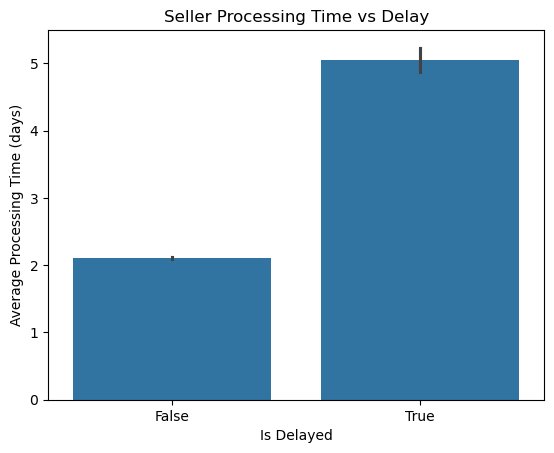

In [110]:
sns.barplot(x='is_delayed',y='seller_processing_time',data=df,)
plt.title('Seller Processing Time vs Delay')
plt.xlabel('Is Delayed')
plt.ylabel('Average Processing Time (days)')
plt.show()

### Insight
Delayed orders have higher seller processing time (5days vs 2days).

### Decision
Reduce seller processing time to decrease delivery delays.

In [80]:
##seller Delay
df['seller_delay']=(df['order_delivered_carrier_date']-df['shipping_limit_date']).dt.days

df.groupby('is_delayed')['seller_delay'].mean()

is_delayed
False   -4.054479
True    -0.955304
Name: seller_delay, dtype: float64

In [104]:
### Which sellers are causing the highest overall delivery delay impact

df_delay = df[df['delay_days'] > 0]

seller_analysis = df_delay.groupby('seller_id').agg({
    'seller_processing_time': 'mean',
    'delay_days': ['mean','count']
})

seller_analysis.columns = ['processing_mean','delay_mean','order_count']

seller_analysis = seller_analysis[seller_analysis['order_count'] > 30]

seller_analysis['impact_score'] = seller_analysis['delay_mean'] * seller_analysis['order_count']

seller_analysis.sort_values(by='impact_score', ascending=False).head()

,processing_mean,delay_mean,order_count,impact_score
seller_id,,,,
4a3ca9315b744ce9f8e9374361493884,2.947674,11.232558,172,1932.0
1f50f920176fa81dab994f9023523100,3.572581,10.588710,124,1313.0
7c67e1448b00f6e969d365cea6b010ab,12.910112,12.314607,89,1096.0
4869f7a5dfa277a7dca6462dcf3b52b2,2.127119,9.245763,118,1091.0
da8622b14eb17ae2831f4ac5b9dab84a,2.183908,11.482759,87,999.0


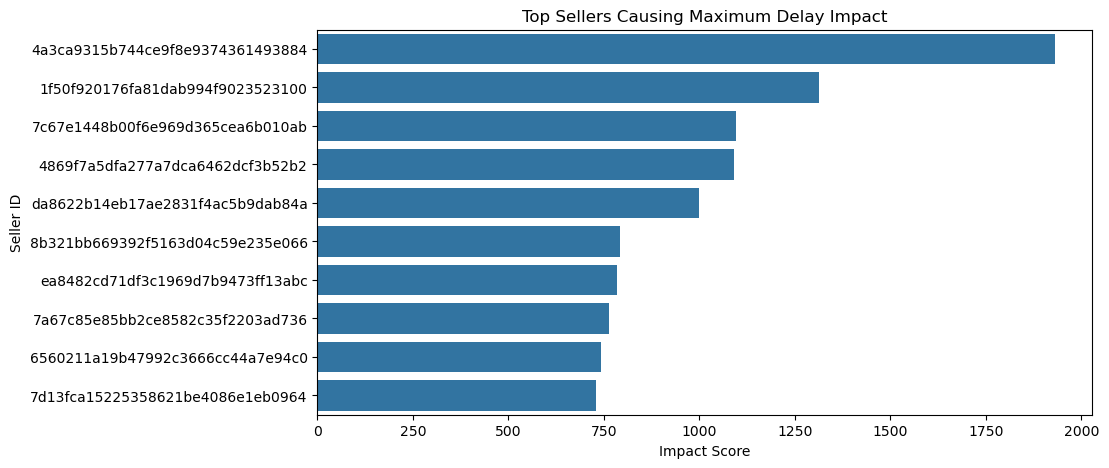

In [122]:
top_seller=seller_analysis.sort_values(by='impact_score',ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x='impact_score',y='seller_id',data=top_seller,)
plt.title('Top Sellers Causing Maximum Delay Impact')
plt.xlabel('Impact Score')
plt.ylabel('Seller ID')
plt.show()

### Insight
A small group of sellers drives a large portion of total delivery delays due to high delay and high order volume

### Decision
Focus on improving the performance of high-impact sellers, as addressing a few key sellers can signigicantly reduce overall delivery delays

In [85]:
df.groupby('is_delayed')['review_score'].agg(['mean','median','count'])

,mean,median,count
is_delayed,,,
False,4.232906,5.0,91526
True,2.271901,1.0,6381


In [106]:
seller_analysis['seller_type']=seller_analysis['processing_mean'].apply(lambda x:'Fast'if x <5 else'Slow')

In [107]:
seller_analysis.groupby('seller_type')['delay_mean'].mean()

seller_type
Fast    10.180491
Slow    10.890798
Name: delay_mean, dtype: float64

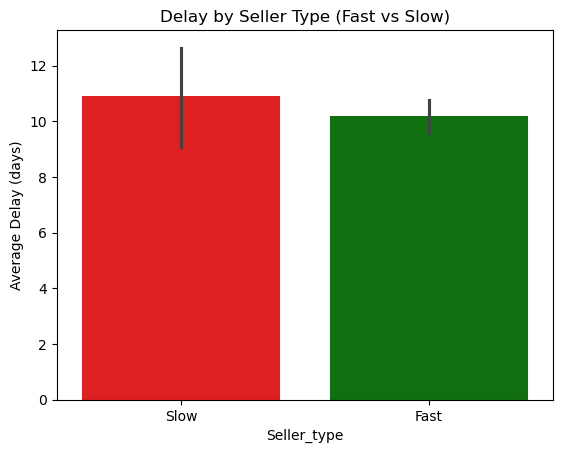

In [116]:
sns.barplot(x='seller_type',y='delay_mean',data=seller_analysis,hue='seller_type',
palette={'Fast':'green','Slow':'red'})
plt.title('Delay by Seller Type (Fast vs Slow)')
plt.xlabel('Seller_type')
plt.ylabel('Average Delay (days)')
plt.show()

### Insight
Fast sellers experience similar delays as slow sellers, indicating that seller processing time is not the main driver of delivery delays.

### Decision
Priortize improvements in logistics (shipping and courier perfromance),as delays are not significantly reduced even with faster seller processing.

### Final Summary
This project analyzes delivery delays to identify key drivers affecting performance. 
The analysis shows that while seller processing time contributes to delays, it is not the primary cause. 
Delays are largely influenced by logistics factors and are concentrated among a small group of high-impact sellers. 
Additionally, in some cases (e.g., specific city-category combinations), delays are distributed across multiple sellers rather than driven by a single source.

### Key Insights
- Delayed orders have higher seller processing time compared to non-delayed orders.
- However, fast and slow sellers experience similar delay levels, indicating seller speed is not the main driver.
- A small number of sellers contribute disproportionately to total delays (high impact score).
- In certain segments (e.g., automotive in Rio de Janeiro), delays are spread across many sellers rather than a few key ones.
- Delivery delays significantly reduce customer satisfaction (lower review scores).

### Recommendation
- Prioritize high-impact sellers, as improving a few key sellers can reduce overall delays significantly.
- Focus on logistics and courier performance, since delays persist even with fast seller processing.
- Monitor regions and product categories with widespread delays to identify operational inefficiencies.
- Implement performance tracking for sellers to maintain consistent processing standards.